# 🎮 **STEAM PRICE INTELLIGENCE SYSTEM**

## 📌 **PROJECT OVERVIEW**

The **Steam Price Intelligence System** is an end-to-end machine learning project designed to analyze Steam game metadata and recommend optimal pricing strategies for indie game developers.

This system combines structured features (genre, reviews, release data, playtime, etc.) with natural language processing on game descriptions to understand how different factors influence game pricing in the Steam marketplace.

The goal is to move beyond simple price prediction and develop a data-driven pricing recommendation framework.

---


## 🎯 **PROBLEM STATEMENT**

Pricing is one of the most critical decisions for indie game developers.

Many games may be:

* Underpriced, leaving potential revenue unrealized
* Overpriced, reducing sales volume
* Priced without sufficient data-driven insight

The objective of this project is to:

* Analyze historical Steam game data
* Identify key features that influence pricing
* Build regression and classification models
* Provide an intelligent price recommendation range based on game attributes

This system aims to help developers make strategic pricing decisions backed by machine learning insights.

---

# **01 – EXPLORATORY DATA ANALYSIS**

This notebook focuses on performing **Exploratory Data Analysis (EDA)** on the Steam dataset to understand its structure, pricing patterns, feature distributions, and potential data quality issues.

The objective of this phase is to:

* Explore dataset structure and feature types
* Identify missing values, outliers, and noise
* Analyze price distribution and skewness
* Examine relationships between pricing and key variables

The insights gained from this analysis guide the **feature engineering strategy** and inform the design of subsequent **modeling approaches**, including structured ML and NLP-based techniques.

---

In [1]:
'''Importing necessary libraries for data analysis and visualization.'''

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Loading the dataset from the specified path into a DataFrame.
df = pd.read_csv('games_march2025_cleaned.csv')

In [3]:
# Displaying the first few rows of the DataFrame to understand its structure and contents.
df.head()

,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,...,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
0,730,Counter-Strike 2,2012-08-21,0,0.00,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",NaN,...,879,5174,350,0,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939,82,96473
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.00,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,NaN,...,0,0,0,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842,68,16720
2,570,Dota 2,2013-07-09,0,0.00,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",“A modern multiplayer masterpiece.” 9.5/10 – D...,...,1536,898,892,0,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595,80,29366
3,271590,Grand Theft Auto V Legacy,2015-04-13,17,0.00,0,"When a young street hustler, a retired bank ro...","When a young street hustler, a retired bank ro...",Grand Theft Auto V for PC offers players the o...,NaN,...,771,7101,74,0,117698,"{'Open World': 32644, 'Action': 23539, 'Multip...",87,1803832,92,17517
4,359550,Tom Clancy's Rainbow Six® Siege,2015-12-01,17,3.99,9,Edition Comparison Ultimate Edition The Tom Cl...,“One of the best first-person shooters ever ma...,"Tom Clancy's Rainbow Six® Siege is an elite, t...",NaN,...,682,2434,306,80,89916,"{'FPS': 9831, 'PvP': 9162, 'e-sports': 9072, '...",84,1168020,76,12608


## **1.DATA OVERVIEW**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89618 entries, 0 to 89617
Data columns (total 47 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   appid                     89618 non-null  int64  
 1   name                      89618 non-null  object 
 2   release_date              89618 non-null  object 
 3   required_age              89618 non-null  int64  
 4   price                     89618 non-null  float64
 5   dlc_count                 89618 non-null  int64  
 6   detailed_description      89421 non-null  object 
 7   about_the_game            89398 non-null  object 
 8   short_description         89498 non-null  object 
 9   reviews                   10401 non-null  object 
 10  header_image              89618 non-null  object 
 11  website                   41114 non-null  object 
 12  support_url               44110 non-null  object 
 13  support_email             78798 non-null  object 
 14  window

In [5]:
df.shape

(89618, 47)

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
appid,89618.0,1.656904e+06,916838.982016,20.0,855052.50,1524730.00,2430852.50,3542350.00
required_age,89618.0,1.836238e-01,1.725594,-1.0,0.00,0.00,0.00,21.00
price,89618.0,7.309623e+00,13.331073,0.0,0.99,4.99,9.99,999.98
dlc_count,89618.0,5.955835e-01,15.351920,0.0,0.00,0.00,0.00,3427.00
metacritic_score,89618.0,2.903245e+00,14.445358,0.0,0.00,0.00,0.00,97.00
achievements,89618.0,2.055233e+01,163.562418,0.0,0.00,5.00,20.00,9821.00
recommendations,89618.0,1.009401e+03,22048.147658,0.0,0.00,0.00,0.00,4401572.00
user_score,89618.0,3.281707e-02,1.615149,0.0,0.00,0.00,0.00,100.00
score_rank,39.0,9.912821e+01,0.695076,98.0,99.00,99.00,100.00,100.00
positive,89618.0,1.269896e+03,31814.411404,0.0,1.00,10.00,58.00,7480813.00


### **KEY FINDINGS**

* The dataset contains **94,948 records and 47 features**, including numerical, categorical, boolean, and text-based fields.
* Several columns contain **missing values**, particularly in metadata-related fields.
* Some features include **negative placeholder values (e.g., -1)** indicating missing or undefined data.
* The target variable **price is highly right-skewed**, with extreme outliers (max ≈ 999.98).
* Engagement-related features (reviews, playtime, recommendations) show **long-tail distributions and high variance**.

These findings highlight the need for **data cleaning, outlier handling, and feature transformation** before modeling.

## **2.MISSING VALUES AND DUPLICATE ANALYSIS**

In [7]:
df_null = df.isnull().sum()
df_null = df_null[df_null > 0] # Identify columns with null values
df_null

detailed_description      197
about_the_game            220
short_description         120
reviews                 79217
website                 48504
support_url             45508
support_email           10820
metacritic_url          86071
notes                   72975
score_rank              89579
dtype: int64

In [8]:
null_df = df.isnull().mean() * 100 > 50
null_df = null_df[null_df].index.tolist()
print("Columns with more than 50% null values:", null_df) # Identify columns with more than 50% null values

Columns with more than 50% null values: ['reviews', 'website', 'support_url', 'metacritic_url', 'notes', 'score_rank']


In [9]:
print(f"Number of duplicated appids: {df.duplicated(subset=['appid']).sum()}") # Check for duplicate appids

Number of duplicated appids: 0


### **KEY FINDINGS**

* **11 out of 47 columns** contain missing values.
* **6 columns have more than 50% missing data**, including:
  `reviews`, `website`, `support_url`, `metacritic_url`, `notes`, and `score_rank`.
* These high-null columns may require **removal or special handling** during preprocessing.
* No duplicate records were found based on the unique identifier (`appid`).

This analysis highlights the need for **missing value treatment and feature selection** before model development.

## **3.PRICE AND RATING DISTRIBUTION ANALYSIS**

In [10]:
# Creating a copy of the original DataFrame for exploratory data analysis (EDA) to avoid modifying the original dataset.
eda_df = df.copy()

def price_range(price):
    '''
    Function to categorize the price of a game into different ranges.
    - 'Free' for games that are free (price = 0)
    - 'Cheap' for games that are less than $10
    - 'Affordable' for games that are between $10 and $30
    - 'Expensive' for games that are $30 or more
    '''
    if price == 0:
        return 'Free'
    elif price < 10:
        return 'Cheap'
    elif price < 30:
        return 'Affordable'
    else:
        return 'Expensive'

In [11]:
#  Applying the price_range function to the 'price' column to create a new column 'price_range' that categorizes the games based on their price.
eda_df['price_range'] = eda_df['price'].apply(price_range)

In [12]:
eda_df['price'].describe()

count    89618.000000
mean         7.309623
std         13.331073
min          0.000000
25%          0.990000
50%          4.990000
75%          9.990000
max        999.980000
Name: price, dtype: float64

In [13]:
print ("Number of free games:", (eda_df['price'] == 0).sum())
print ("Number of games over 500:", (eda_df['price'] > 500).sum())
print ("The most expensive game is:", eda_df.loc[eda_df['price'].idxmax(), 'name'], "with a price of $", eda_df['price'].max())
print ("The cheapest game is:", eda_df.loc[eda_df['price'].idxmin(), 'name'], "with a price of $", eda_df['price'].min())

Number of free games: 14160
Number of games over 500: 3
The most expensive game is: The Leverage Game Business Edition with a price of $ 999.98
The cheapest game is: Counter-Strike 2 with a price of $ 0.0


In [14]:
eda_df['metacritic_score'].describe()

count    89618.000000
mean         2.903245
std         14.445358
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         97.000000
Name: metacritic_score, dtype: float64

In [15]:
eda_df['user_score'].describe()

count    89618.000000
mean         0.032817
std          1.615149
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        100.000000
Name: user_score, dtype: float64

In [16]:
# Identifying games that are zero-rated by either user score or metacritic score,
# which could indicate potential issues with the data or games that have not been rated yet.
zero_rated_games = eda_df[(eda_df['user_score'] == 0) | (eda_df['metacritic_score'] == 0)]

In [17]:
cols = ['name','user_score','metacritic_score','num_reviews_total']
zero_rated_games = zero_rated_games[cols]

In [18]:
zero_rated_games.describe()

,user_score,metacritic_score,num_reviews_total
count,89617.000000,89617.000000,8.961700e+04
mean,0.031757,2.902463,1.315503e+03
std,1.583697,14.443540,3.542389e+04
min,0.000000,0.000000,-1.000000e+00
25%,0.000000,0.000000,-1.000000e+00
50%,0.000000,0.000000,1.500000e+01
75%,0.000000,0.000000,8.100000e+01
max,100.000000,97.000000,8.632939e+06


### **KEY FINDINGS**

* **Price Distribution**

  * 75% of games are priced below **$10**, indicating a strong concentration of low-cost titles.
  * The dataset contains **19,420 free games**, forming a significant portion of the market.
  * Only **3 games are priced above $500**, confirming extreme price outliers.
  * The most expensive game is **“The Leverage Game Business Edition” ($999.98)**.
  * The cheapest game is **“Counter-Strike 2” ($0.0)**.
  * Overall, the price distribution is **highly right-skewed with rare premium outliers**, requiring transformation or outlier handling before modeling.

* **Metacritic and User Score Distribution**

  * A large portion of games have scores recorded as **0**, likely indicating missing or unrated entries rather than true zero ratings.
  * Score distributions are heavily skewed and sparse at higher values.

* **Zero-Rated Games Analysis**

  * Many games with `user_score = 0` or `metacritic_score = 0` still show **non-zero review counts**, suggesting placeholder or inconsistent scoring.
  * Review-related fields contain **negative values (-1)**, which represent undefined data.
  * These placeholder values must be cleaned or converted before feature engineering.

---

## **4.FREE KEYWORD SIGNAL ANALYSIS**

In [19]:
all_genres = (
    df['genres']
    .fillna('')
    .str.split(',')
    .explode()
    .str.strip()
    .unique()
)

all_categories = (
    df['categories']
    .fillna('')
    .str.split(',')
    .explode()
    .str.strip()
    .unique()
)

all_tags = (
    df['tags']
       .fillna('')
       .str.split(',')
       .explode()
       .str.strip()
       .unique()
)
print("Free to Play in categories (exact)?", "Free to Play" in all_categories)
print("Free to Play in genres (exact)?", "Free to Play" in all_genres)
print("Free to Play in tags (exact)?", "Free to Play" in all_tags)

Free to Play in categories (exact)? False
Free to Play in genres (exact)? False
Free to Play in tags (exact)? False


In [20]:
# Genres
print("Genres containing 'free':")
print([g for g in all_genres if 'free' in g.lower()])

# Categories
print("Categories containing 'free':")
print([c for c in all_categories if 'free' in c.lower()])

# Tags
print("Tags containing 'free':")
print([t for t in all_tags if 'free' in t.lower()])

Genres containing 'free':
["'Free To Play']", "'Free To Play'", "['Free To Play'", "['Free To Play']"]
Categories containing 'free':
[]
Tags containing 'free':
["{'Free to Play': 59933", "{'Free to Play': 62868", "{'Free to Play': 2170", "{'Free to Play': 3512", "{'Free to Play': 15768", "{'Free to Play': 6063", "{'Free to Play': 36916", "{'Free to Play': 4129", "'Free to Play': 5342", "'Free to Play': 616", "'Free to Play': 1871", "{'Free to Play': 17278", "{'Free to Play': 2195", "'Free to Play': 7091", "'Free to Play': 963", "'Free to Play': 373", "{'Free to Play': 890", "'Free to Play': 1910", "'Free to Play': 1935", "'Free to Play': 98713", "{'Free to Play': 695", "{'Free to Play': 1304", "{'Free to Play': 494", "{'Free to Play': 2657", "'Free to Play': 460", "{'Free to Play': 627", "'Free to Play': 168", "'Free to Play': 917", "'Free to Play': 1489", "{'Free to Play': 3970", "{'Free to Play': 735", "'Free to Play': 9191", "{'Free to Play': 3953", "{'Free to Play': 2761", "{'Free 

In [21]:
experimental_df = df.copy()
experimental_df['is_free'] = experimental_df['price'].apply(lambda x: 1 if x == 0 else 0)
experimental_df['has_free_genre'] = experimental_df['genres'].str.contains('free', case=False, na=False)
experimental_df['has_free_categories'] = experimental_df['categories'].str.contains('free', case=False, na=False)
experimental_df['has_free_tags'] = experimental_df['tags'].str.contains('free', case=False, na=False)

print(f"{'-'*5}Genres{'-'*5}")
print(pd.crosstab(experimental_df['has_free_genre'], experimental_df['is_free']))
print(f"Mean of is_free for games with free genre: {experimental_df[experimental_df['has_free_genre']]['is_free'].mean()}")

print(f"{'-'*5}Categories{'-'*5}")
print(pd.crosstab(experimental_df['has_free_categories'], experimental_df['is_free']))
print(f"Mean of is_free for games with free categories: {experimental_df[experimental_df['has_free_categories']]['is_free'].mean()}")

print(f"{'-'*5}Tags{'-'*5}")
print(pd.crosstab(experimental_df['has_free_tags'], experimental_df['is_free']))
print(f"Mean of is_free for games with free tags: {experimental_df[experimental_df['has_free_tags']]['is_free'].mean()}")

-----Genres-----
is_free             0     1
has_free_genre             
False           75386  5365
True               72  8795
Mean of is_free for games with free genre: 0.9918800045111086
-----Categories-----
is_free                  0      1
has_free_categories              
False                75458  14160
Mean of is_free for games with free categories: nan
-----Tags-----
is_free            0      1
has_free_tags              
False          75170  10333
True             288   3827
Mean of is_free for games with free tags: 0.9300121506682868


### **KEY FINDINGS**:
* The term **“Free to Play”** does not consistently appear as an exact match in `categories`, `genres`, or `tags`, indicating inconsistent formatting across metadata fields.

* Presence of "free" in:

  * **Genres** → Extremely strong indicator

    * ~99% of games with “free” in genre are actually free.
  * **Tags** → Strong predictive signal

    * ~93% of games with “free” in tags are free.
  * **Categories** → No meaningful signal detected.

* However, since the objective is to predict price using **pre-release structured signals**, relying on explicit “Free to Play” keyword presence may introduce:

  * Data leakage risk
  * Over-reliance on obvious metadata indicators

* Based on this analysis, `genres` and `tags` were dropped from structured modeling to avoid leakage and maintain generalizable price prediction logic.

This ensures the model learns pricing patterns from broader attributes rather than direct keyword shortcuts.

---

## **5.PRICE DISTRIBUTION VISUAL ANALYSIS**

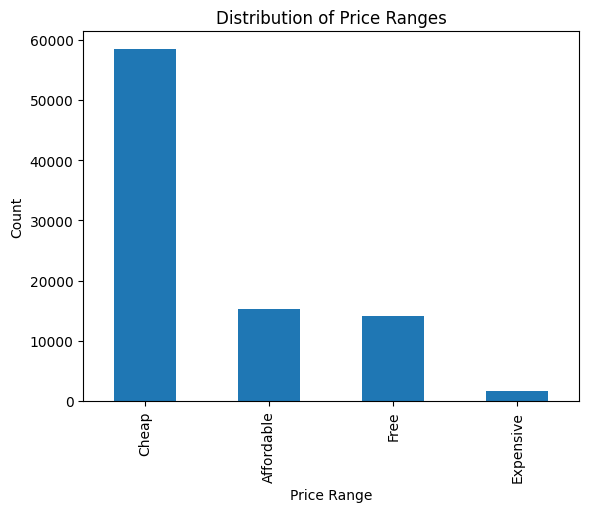

In [22]:
eda_df['price_range'].value_counts().plot(kind='bar')
plt.title('Distribution of Price Ranges')
plt.xlabel('Price Range')
plt.ylabel('Count')
plt.show()

Text(0.5, 1.0, 'Box Plot of Game Prices')

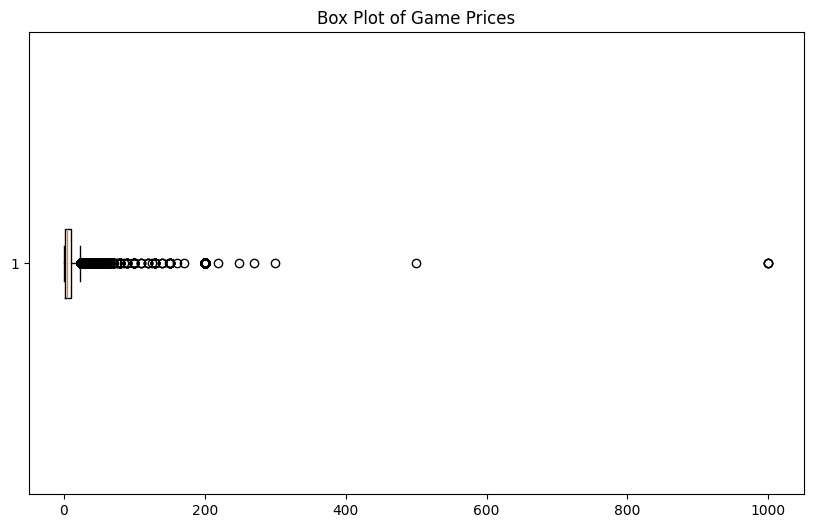

In [23]:
# box plot to visualize price distribution and outliers
plt.figure(figsize=(10, 6))
plt.boxplot(eda_df['price'],vert=False)
plt.title('Box Plot of Game Prices')

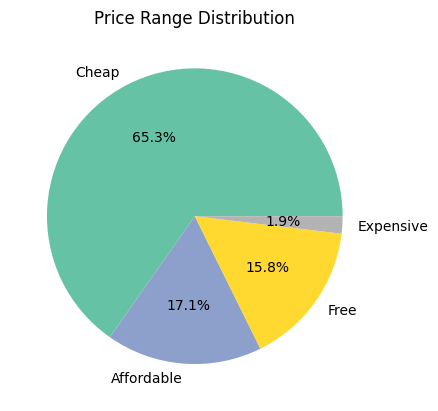

In [24]:
# plot pie chart for price range distribution
eda_df['price_range'].value_counts().plot(kind='pie', autopct='%1.1f%%',colormap='Set2')
plt.title('Price Range Distribution')
plt.ylabel('')
plt.show()

### **KEY FINDINGS**

* The majority of games fall under the **“Cheap” category (~61.6%)**, indicating strong dominance of low-priced titles.

* **Free games (~20.5%)** form a significant portion of the marketplace.

* **Affordable mid-range games (~16.1%)** represent a moderate share.

* **Expensive games (~1.8%)** are extremely rare, confirming a highly imbalanced pricing structure.

* The boxplot clearly shows:

  * Strong **right-skewness** in price distribution.
  * Heavy concentration near lower price values.
  * Presence of **extreme outliers**, including premium titles approaching $1000.

Overall, the Steam marketplace exhibits a **long-tail pricing pattern**, where most games are low-cost while a very small number of premium titles create significant variance.

This confirms the need for **outlier handling and potential log transformation** before regression modeling.


## **CONCLUSION - EDA**

The exploratory analysis provided a structured understanding of the Steam dataset’s composition, pricing patterns, and data quality.

Key observations from this phase include:

* The dataset contains **94,948 records with no duplicate `appid` entries**, ensuring entity-level integrity.
* Several columns contain **substantial missing values**, with some features exceeding 50% nulls, requiring removal or careful preprocessing.
* The **price distribution is highly right-skewed**, dominated by low-cost and free games, with a few extreme outliers.
* Engagement and rating features exhibit **long-tail distributions and placeholder values**, indicating the need for data cleaning and transformation.
* The dataset combines **structured numerical features and rich textual metadata**, supporting both regression and transformer-based NLP modeling.

These insights guide the feature engineering strategy and modeling decisions in the next phase.

---

### ✅ **PHASE 01 – EXPLORATORY DATA ANALYSIS COMPLETED**

➡ Moving to **Phase 02 – Data Preprocessing and Feature Engineering**

---